# KNN Pipeline Tutorial - CSTH Fault Detection

This notebook provides a hands-on introduction to using the KNN pipeline for time series classification on the CSTH dataset.

## Contents
1. Setup and Data Loading
2. Quick Start: Single Evaluation
3. Understanding the Pipeline
4. Hyperparameter Tuning
5. Distance Metrics Comparison
6. Making Predictions

## 1. Setup and Data Loading

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

p = Path.cwd()
while p != p.parent and not (p / "src").exists():
    p = p.parent

if not (p / "src").exists():
    raise RuntimeError("Could not find src/ up the directory tree")

sys.path.insert(0, str(p))

from src.knn_pipeline import (
    evaluate_knn,
    grid_search_k,
    PipelineConfig,
    TimeSeriesPreprocessor,
)
from src.run_csth import load_csth_dataset, create_groups_for_split


# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

In [3]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    p = Path(start or Path.cwd()).resolve()
    for parent in [p] + list(p.parents):
        if (parent / "data" / "raw").exists():
            return parent
    raise FileNotFoundError(f"Could not find 'data/raw' starting from {p}")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))  # optional: fixes imports from src/

# Load CSTH dataset
data_dir = ROOT / "data" / "raw"
splits = load_csth_dataset(data_dir)

X_train, y_train = splits["train"]
X_val,   y_val   = splits["val"]
X_test,  y_test  = splits["test"]

print("Dataset loaded successfully!")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")



Loading CSTH Dataset (Continuous Stirred Tank Heater)

Loading train...
  Shape: (6300, 3, 200) (samples x timesteps x features)
  Classes: 3151 normal, 3149 fault
  Data range: [0.000, 1.000]
  Data mean: 0.252, std: 0.145

Loading val...
  Shape: (900, 3, 200) (samples x timesteps x features)
  Classes: 452 normal, 448 fault
  Data range: [0.000, 1.000]
  Data mean: 0.251, std: 0.145

Loading test...
  Shape: (1800, 3, 200) (samples x timesteps x features)
  Classes: 897 normal, 903 fault
  Data range: [0.000, 1.000]
  Data mean: 0.251, std: 0.146

Dataset loaded successfully!
Train: (6300, 3, 200), Val: (900, 3, 200), Test: (1800, 3, 200)


/home/user/Desktop/KNN_pse/src/run_csth.py:171: UserWarning: Expected 3 features (cold water flow, tank level, temperature), got 200
  warnings.warn(f"Expected 3 features (cold water flow, tank level, temperature), "
/home/user/Desktop/KNN_pse/src/run_csth.py:174: UserWarning: Expected 200 timesteps, got 3
  warnings.warn(f"Expected 200 timesteps, got {n_timesteps}")


## 2. Quick Start: Single Evaluation

Let's run a simple evaluation on the validation set with default parameters.

In [7]:
# Create artificial groups for cross-validation
groups_val = create_groups_for_split(len(y_val), n_groups=10)

# Configure pipeline
config = PipelineConfig(
    k=10,
    distance_metric='euclidean',
    standardize=True,
    use_pca=True,
    n_splits=5,
    verbose=1,
)

# Run evaluation
result = evaluate_knn(X_val, y_val, groups_val, config)

print("\n" + "="*60)
print("Results:")
print("="*60)
print(result)

Starting EUCLIDEAN-KNN evaluation
Data: 900 samples, 10 groups, 5 folds
Config: k=10, standardize=True, PCA=True

=== Fold 1/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.802, F1: 0.800, Time: 0.4s

=== Fold 2/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.769, F1: 0.769, Time: 0.2s

=== Fold 3/5 ===
PCA: Avg 96.3% variance retained per timestep
Fold accuracy: 0.786, F1: 0.785, Time: 0.2s

=== Fold 4/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.802, F1: 0.801, Time: 0.1s

=== Fold 5/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.767, F1: 0.766, Time: 0.2s

Final Results (EUCLIDEAN-KNN, k=10)
Accuracy: 0.786
F1 (weighted): 0.784
F1 (macro): 0.784
Total time: 1.1s

Results:
Accuracy: 0.786
F1 (weighted): 0.784
F1 (macro): 0.784
Time: 1.12s



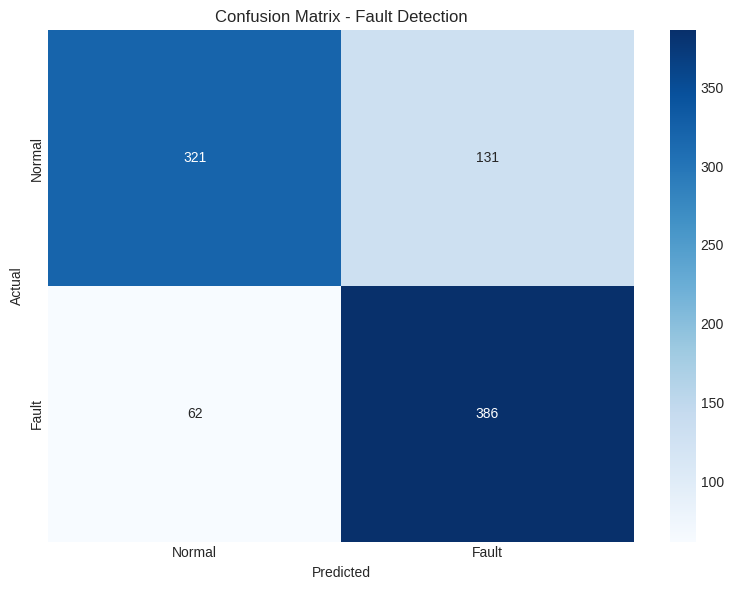

In [8]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(result.confusion_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fault'],
            yticklabels=['Normal', 'Fault'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Fault Detection')
plt.tight_layout()
plt.show()

## 3. Understanding the Pipeline

Let's examine each component of the pipeline.

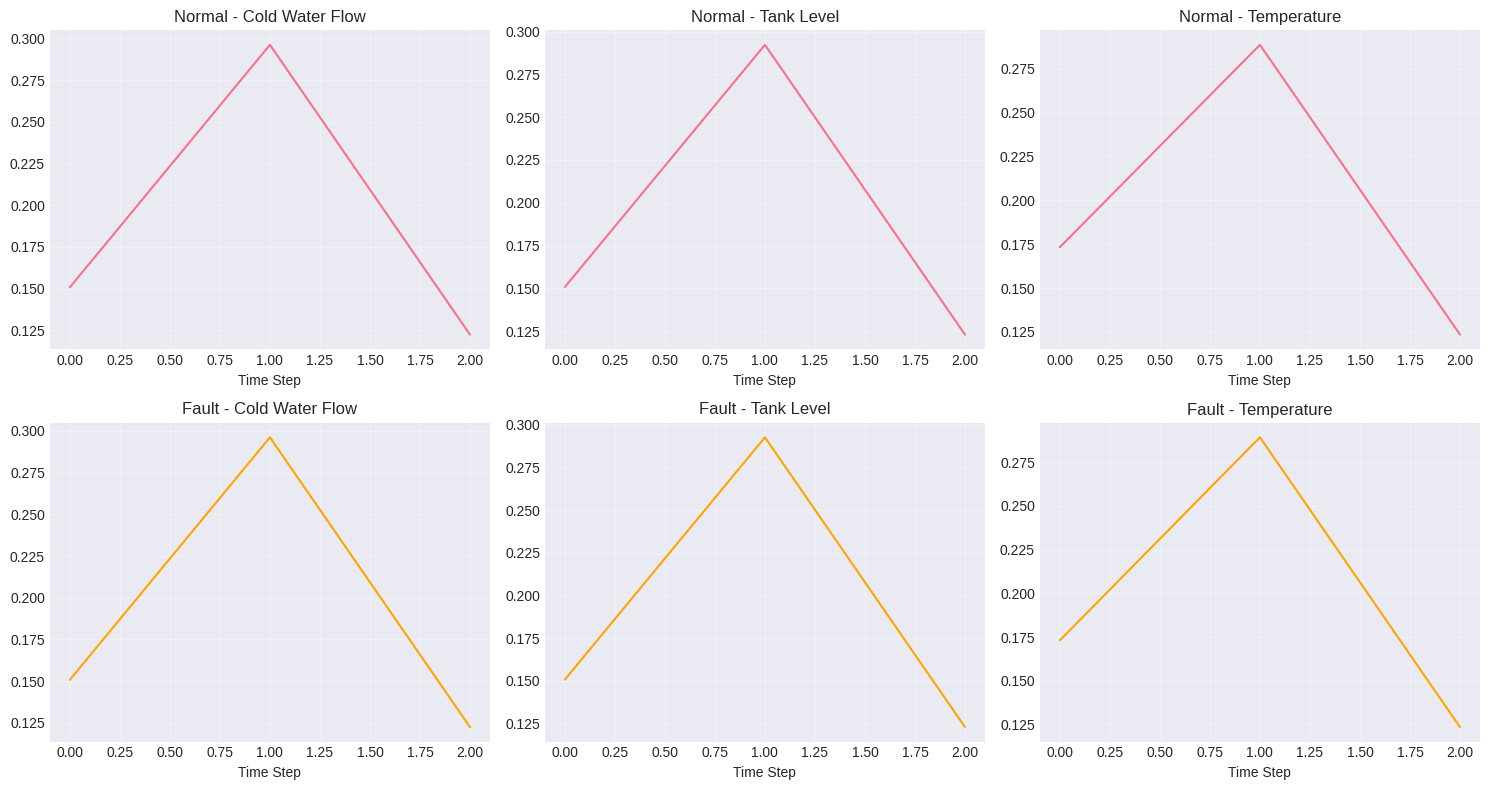

In [6]:
# Visualize sample time series
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_names = ['Cold Water Flow', 'Tank Level', 'Temperature']

# Plot normal sample
normal_idx = np.where(y_val == 0)[0][0]
for i, (ax, name) in enumerate(zip(axes[0], feature_names)):
    ax.plot(X_val[normal_idx, :, i])
    ax.set_title(f'Normal - {name}')
    ax.set_xlabel('Time Step')
    ax.grid(True, alpha=0.3)

# Plot fault sample
fault_idx = np.where(y_val == 1)[0][0]
for i, (ax, name) in enumerate(zip(axes[1], feature_names)):
    ax.plot(X_val[fault_idx, :, i], color='orange')
    ax.set_title(f'Fault - {name}')
    ax.set_xlabel('Time Step')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Examine preprocessing effects
preprocessor = TimeSeriesPreprocessor(config)
X_val_processed = preprocessor.fit_transform(X_val)

print(f"Original shape: {X_val.shape}")
print(f"Processed shape: {X_val_processed.shape}")
print(f"\nDimensionality reduction: {X_val.shape[2]} → {X_val_processed.shape[2]} features")
print(f"Compression ratio: {X_val_processed.shape[2] / X_val.shape[2]:.2%}")

PCA: Avg 96.2% variance retained per timestep
Original shape: (900, 3, 200)
Processed shape: (900, 3, 2)

Dimensionality reduction: 200 → 2 features
Compression ratio: 1.00%


## 4. Hyperparameter Tuning

Find the optimal k value using grid search.

In [11]:
# Grid search over k values
k_values = [1, 3, 5, 7, 10, 15, 20, 25, 30, 35, 40]

base_config = PipelineConfig(
    distance_metric='euclidean',
    standardize=True,
    use_pca=True,
    n_splits=5,
    verbose=0,  # Suppress per-fold output
)

results = grid_search_k(X_val, y_val, groups_val, k_values, base_config)


Grid Search: k = [1, 3, 5, 7, 10, 15, 20, 25, 30, 35, 40]

k= 1 | Acc: 0.729 | F1w: 0.728 | F1m: 0.728

k= 3 | Acc: 0.743 | F1w: 0.743 | F1m: 0.743

k= 5 | Acc: 0.743 | F1w: 0.743 | F1m: 0.743

k= 7 | Acc: 0.762 | F1w: 0.762 | F1m: 0.762

k=10 | Acc: 0.786 | F1w: 0.784 | F1m: 0.784

k=15 | Acc: 0.790 | F1w: 0.787 | F1m: 0.787

k=20 | Acc: 0.787 | F1w: 0.783 | F1m: 0.783

k=25 | Acc: 0.796 | F1w: 0.791 | F1m: 0.792

k=30 | Acc: 0.793 | F1w: 0.788 | F1m: 0.788

k=35 | Acc: 0.791 | F1w: 0.786 | F1m: 0.786

k=40 | Acc: 0.790 | F1w: 0.784 | F1m: 0.784

Best k: 25 (F1-weighted: 0.791)


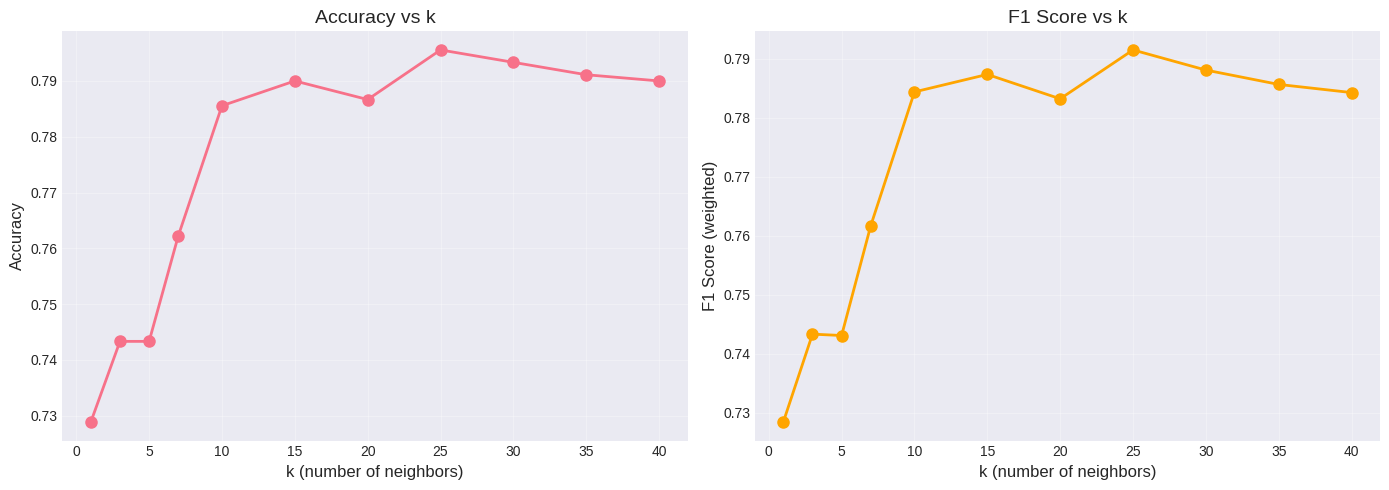


Best k: 25
Best F1 Score: 0.7915


In [12]:
# Plot results
k_vals = list(results.keys())
accuracies = [results[k].accuracy for k in k_vals]
f1_scores = [results[k].f1_weighted for k in k_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_vals, accuracies, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('k (number of neighbors)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs k', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_vals, f1_scores, 'o-', color='orange', linewidth=2, markersize=8)
axes[1].set_xlabel('k (number of neighbors)', fontsize=12)
axes[1].set_ylabel('F1 Score (weighted)', fontsize=12)
axes[1].set_title('F1 Score vs k', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best k
best_k = max(results.keys(), key=lambda k: results[k].f1_weighted)
print(f"\nBest k: {best_k}")
print(f"Best F1 Score: {results[best_k].f1_weighted:.4f}")

## 5. Distance Metrics Comparison

Compare Euclidean vs DTW distance metrics.

In [13]:
# Test both metrics
metrics_results = {}

for metric in ['euclidean', 'dtw']:
    print(f"\nTesting {metric.upper()}...")
    
    config = PipelineConfig(
        k=best_k,
        distance_metric=metric,
        standardize=True,
        use_pca=True,
        n_splits=5,
        dtw_window=0.1 if metric == 'dtw' else None,
        verbose=1,
    )
    
    result = evaluate_knn(X_val, y_val, groups_val, config)
    metrics_results[metric] = result
    
    print(f"{metric.upper()}: Acc={result.accuracy:.4f}, F1={result.f1_weighted:.4f}")


Testing EUCLIDEAN...
Starting EUCLIDEAN-KNN evaluation
Data: 900 samples, 10 groups, 5 folds
Config: k=25, standardize=True, PCA=True

=== Fold 1/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.824, F1: 0.820, Time: 0.7s

=== Fold 2/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.797, F1: 0.794, Time: 0.2s

=== Fold 3/5 ===
PCA: Avg 96.3% variance retained per timestep
Fold accuracy: 0.764, F1: 0.759, Time: 0.4s

=== Fold 4/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.813, F1: 0.809, Time: 1.1s

=== Fold 5/5 ===
PCA: Avg 96.2% variance retained per timestep
Fold accuracy: 0.779, F1: 0.775, Time: 0.9s

Final Results (EUCLIDEAN-KNN, k=25)
Accuracy: 0.796
F1 (weighted): 0.791
F1 (macro): 0.792
Total time: 3.4s
EUCLIDEAN: Acc=0.7956, F1=0.7915

Testing DTW...
Starting DTW-KNN evaluation
Data: 900 samples, 10 groups, 5 folds
Config: k=25, standardize=True, PCA=True

=== Fold 1/5 ===
PCA: Avg 96.2% variance retained per times

In [14]:
# Compare metrics
comparison = {
    'Metric': ['Euclidean', 'DTW'],
    'Accuracy': [metrics_results['euclidean'].accuracy, 
                 metrics_results['dtw'].accuracy],
    'F1 Score': [metrics_results['euclidean'].f1_weighted,
                 metrics_results['dtw'].f1_weighted],
    'Time (s)': [metrics_results['euclidean'].timing['total'],
                 metrics_results['dtw'].timing['total']],
}

import pandas as pd
df_comparison = pd.DataFrame(comparison)
print("\nMetrics Comparison:")
print(df_comparison.to_string(index=False))


Metrics Comparison:
   Metric  Accuracy  F1 Score  Time (s)
Euclidean  0.795556  0.791472  3.384748
      DTW  0.793333  0.789845 34.807001


## 6. Making Predictions

Train on validation set and predict on a few test samples.

In [15]:
from knn_pipeline import pairwise_euclidean_matrix, knn_vote_from_dist

# Use best configuration
best_config = PipelineConfig(
    k=best_k,
    distance_metric='euclidean',
    standardize=True,
    use_pca=True,
    verbose=0,
)

# Fit preprocessing on validation set
preprocessor = TimeSeriesPreprocessor(best_config)
X_val_proc = preprocessor.fit_transform(X_val)

# Take first 10 test samples
X_test_sample = X_test[:10]
y_test_sample = y_test[:10]
X_test_proc = preprocessor.transform(X_test_sample)

# Compute distances and predict
D = pairwise_euclidean_matrix(X_test_proc, X_val_proc)
y_pred, y_proba = knn_vote_from_dist(D, y_val, k=best_k, weighted=True)

# Display results
label_names = {0: 'Normal', 1: 'Fault'}
print("\nPredictions on Test Samples:")
print("="*60)
for i in range(len(y_test_sample)):
    true_label = label_names[y_test_sample[i]]
    pred_label = label_names[y_pred[i]]
    confidence = y_proba[i, y_pred[i]]
    status = "✓" if y_test_sample[i] == y_pred[i] else "✗"
    
    print(f"Sample {i+1}: True={true_label:6s} | Pred={pred_label:6s} | "
          f"Confidence={confidence:.2%} {status}")


Predictions on Test Samples:
Sample 1: True=Fault  | Pred=Fault  | Confidence=55.98% ✓
Sample 2: True=Normal | Pred=Normal | Confidence=100.00% ✓
Sample 3: True=Normal | Pred=Normal | Confidence=100.00% ✓
Sample 4: True=Fault  | Pred=Fault  | Confidence=73.41% ✓
Sample 5: True=Fault  | Pred=Fault  | Confidence=57.55% ✓
Sample 6: True=Normal | Pred=Normal | Confidence=97.03% ✓
Sample 7: True=Fault  | Pred=Fault  | Confidence=63.31% ✓
Sample 8: True=Fault  | Pred=Fault  | Confidence=92.76% ✓
Sample 9: True=Normal | Pred=Normal | Confidence=56.64% ✓
Sample 10: True=Fault  | Pred=Fault  | Confidence=74.57% ✓


## Summary

This tutorial covered:
- Loading and visualizing CSTH dataset
- Running KNN evaluation with cross-validation
- Hyperparameter tuning (k selection)
- Comparing distance metrics
- Making predictions on new data

Next steps:
- Explore the EDA notebook for deeper data analysis
- Run full experiments using `run_csth.py`
- Analyze results in the results visualization notebook